In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl

from nucleo.metrics.utils import clc_distrib

In [10]:
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
data_frame = pl.read_csv(
    root,
    separator="\t"
)
print(data_frame)

shape: (66_989, 6)
┌────────┬────────┬────────┬─────────┬───────────┬─────────────────┐
│ chr    ┆ start  ┆ end    ┆ smt_pos ┆ smt_value ┆ fuzziness_score │
│ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---             │
│ str    ┆ i64    ┆ i64    ┆ i64     ┆ f64       ┆ f64             │
╞════════╪════════╪════════╪═════════╪═══════════╪═════════════════╡
│ chrI   ┆ 80     ┆ 228    ┆ 154     ┆ 160.0     ┆ 62.229963       │
│ chrI   ┆ 183    ┆ 331    ┆ 257     ┆ 560.0     ┆ 51.164821       │
│ chrI   ┆ 343    ┆ 491    ┆ 417     ┆ 560.0     ┆ 51.520939       │
│ chrI   ┆ 463    ┆ 611    ┆ 537     ┆ 160.0     ┆ 63.879253       │
│ chrI   ┆ 591    ┆ 739    ┆ 665     ┆ 160.0     ┆ 68.714923       │
│ …      ┆ …      ┆ …      ┆ …       ┆ …         ┆ …               │
│ chrXVI ┆ 942744 ┆ 942892 ┆ 942818  ┆ 56240.0   ┆ 42.835329       │
│ chrXVI ┆ 943093 ┆ 943241 ┆ 943167  ┆ 8080.0    ┆ 44.624281       │
│ chrXVI ┆ 943256 ┆ 943404 ┆ 943330  ┆ 3680.0    ┆ 52.267879       │
│ chrXVI ┆ 9462

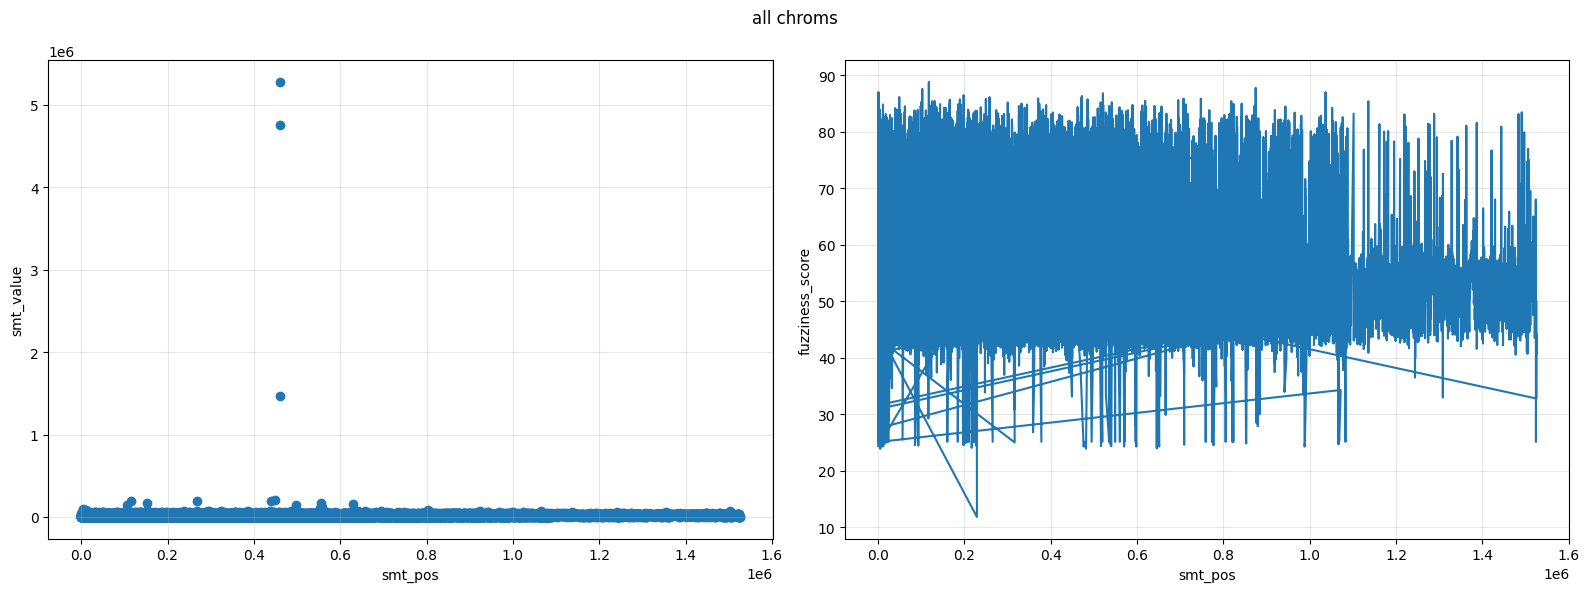

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6))
fig.suptitle("all chroms")

ax1.scatter(data_frame["smt_pos"].to_numpy(), data_frame["smt_value"].to_numpy())
ax1.set_xlabel("smt_pos")
ax1.set_ylabel("smt_value")
ax1.grid(True, which="both", alpha=0.3)

ax2.plot(data_frame["smt_pos"].to_numpy(), data_frame["fuzziness_score"].to_numpy())
ax2.set_xlabel("smt_pos")
ax2.set_ylabel("fuzziness_score")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:

def select_region(df, chrom=None, region=None, gap=np.inf):

    condition = pl.col("smt_value") < gap

    if chrom is not None:
        condition &= pl.col("chr") == chrom

    if region is not None:
        condition &= pl.col("smt_pos").is_between(*region)

    return df.filter(condition)

chrom   = None
region  = [200_000, 300_000]
gap     = 1e6

data_filtered = select_region(
    data_frame,
    chrom=chrom,
    region = region,
    gap=1e6,
)

# Extract arrays
CHROMOSOMES     = data_filtered["chr"].to_numpy()
smt_pos         = data_filtered["smt_pos"].to_numpy()
smt_value       = data_filtered["smt_value"].to_numpy()
fuzziness_score = data_filtered["fuzziness_score"].to_numpy()

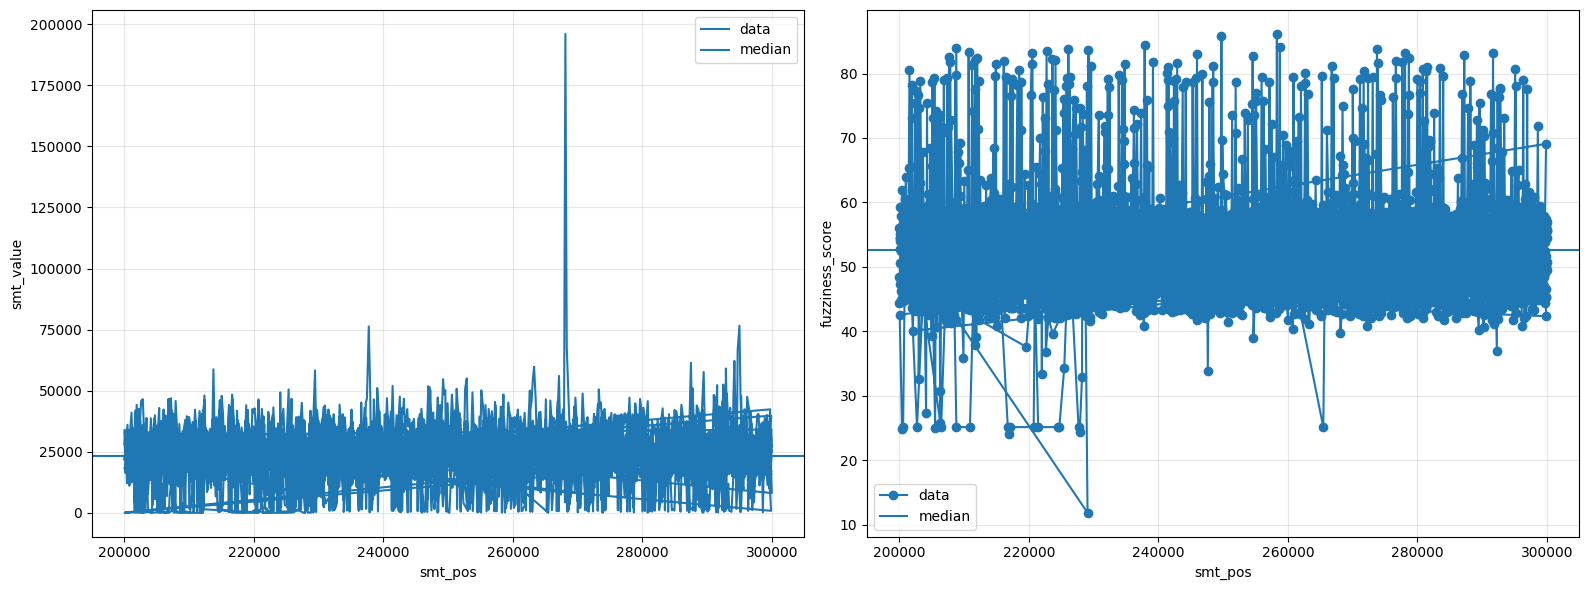

In [63]:
# Plotting
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6))

ax1.plot(smt_pos, smt_value, label="data")
ax1.axhline(y=np.median(smt_value), label="median")
ax1.set_xlabel("smt_pos")
ax1.set_ylabel("smt_value")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="best")

ax2.plot(smt_pos, fuzziness_score, marker="o", label="data")
ax2.axhline(y=np.median(fuzziness_score), label="median")
ax2.set_xlabel("smt_pos")
ax2.set_ylabel("fuzziness_score")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(loc="best")

plt.tight_layout()
plt.show()

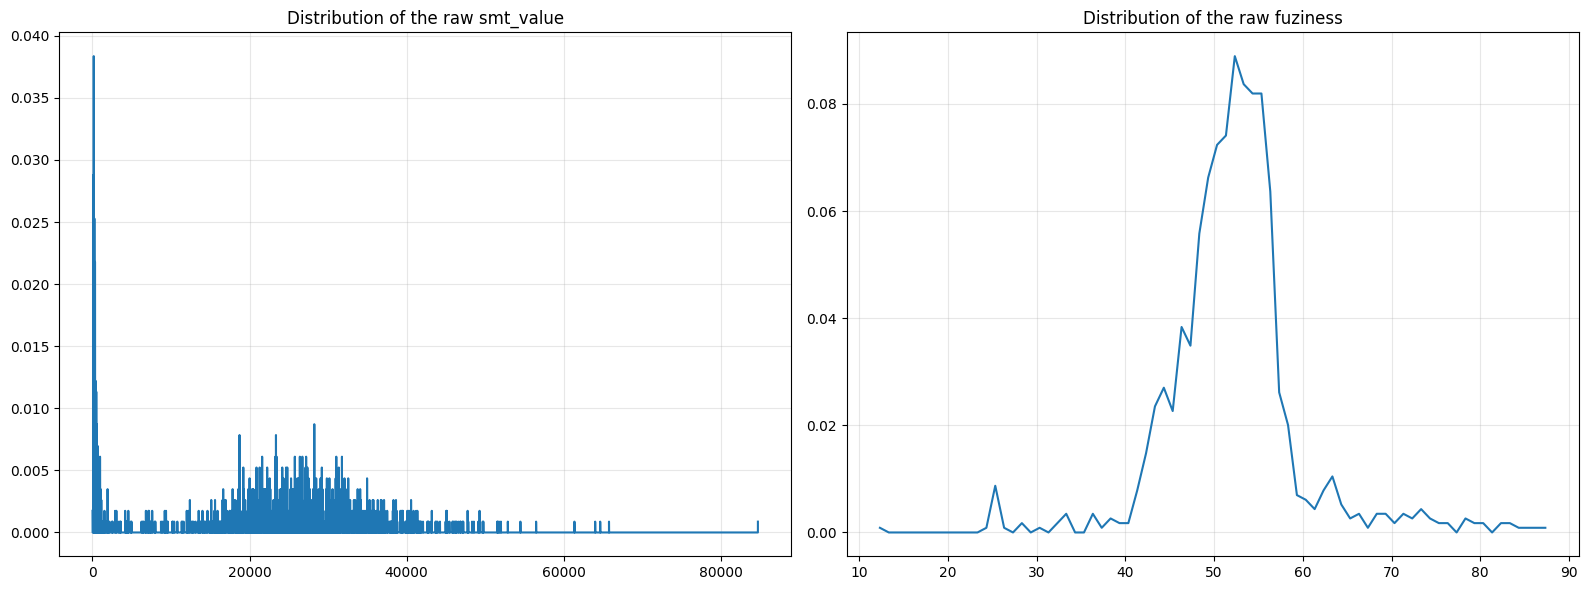

In [ ]:
# Distributions
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6))

x1,y1 = clc_distrib(
    data=smt_value,
    first_bin=np.min(smt_value),
    last_bin=np.max(smt_value),
    bin_width=1
)
ax1.plot(x1, y1)
ax1.set_title("Distribution of the raw smt_value")
ax1.grid(True, which="both", alpha=0.3)

x2,y2 = clc_distrib(
    data=fuzziness_score,
    first_bin=np.min(fuzziness_score),
    last_bin=np.max(fuzziness_score),
    bin_width=1
)
ax2.plot(x2, y2)
ax2.set_title("Distribution of the raw fuziness")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

[103 160 120 ... 106 461 286]
1146
1147


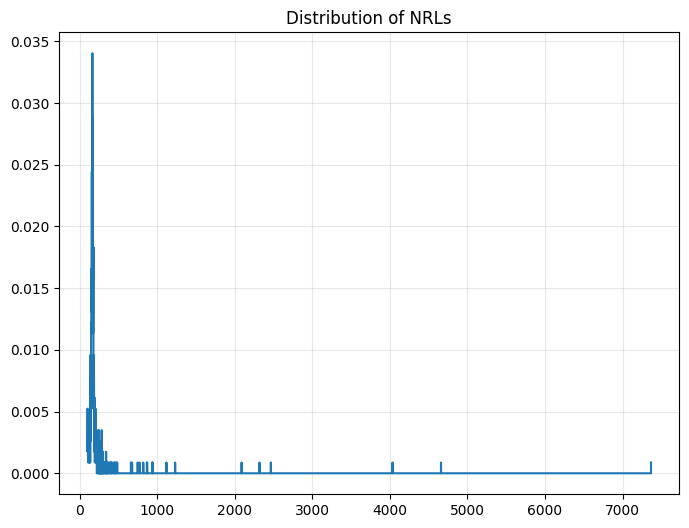

In [ ]:
NRLs = np.diff(smt_pos)
print(NRLs)

print(len(NRLs))
print(len(fuzziness_score))

# # Distributions
# fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(16, 6))

x3,y3 = clc_distrib(
    data=NRLs,
    first_bin=np.min(NRLs),
    last_bin=np.max(NRLs),
    bin_width=1
)
plt.figure(figsize=(8,6))
plt.plot(x3, y3)
plt.title("Distribution of NRLs")
plt.grid(True, which="both", alpha=0.3)
# plt.loglog(True)
plt.show()


# x2,y2 = clc_distrib(
#     data=fuzziness_score, 
#     first_bin=np.min(fuzziness_score),
#     last_bin=np.max(fuzziness_score),
#     bin_width=1
# )
# ax2.plot(x2, y2)
# ax2.set_title("Distribution of the raw fuziness")
# ax2.grid(True, which="both", alpha=0.3)

# plt.tight_layout()
# plt.show()


